In [ ]:
import pathlib
import tempfile
import urllib.request

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
import marimo as mo
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import numpy as np
import pandas as pd
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-08-01T13:16:42.170953+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1062-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

numpy     : 2.1.2
matplotlib: 3.9.2
teeplot   : 1.4.2
pandas    : 2.2.3
marimo    : 0.23.2

```

# Exploratory edge sparsity (2026-07-30): loss vs. n and over time

Downloads the collated timeseries parquet file for the
`2026-07-30-exploratory-edge-sparsity` SLURM batch job (see
`slurm/2026-07-30/`) from OSF, then renders three 2x2-panel figures
-- rows = L1 condition (with L1 / without L1), columns = training-set
size (3-class / 5-class) -- covering all 4 swept (l1_scale, l2_scale,
n_classes) conditions in one glance apiece:

1. Final testing / training (actual) chi^2 error vs. `n_zero_edges`
   (how many of the GRN's 256 possible regulatory edges were zeroed),
   median with a shaded [min, max] band across the 10 replicate
   seeds at each n.
2. Testing chi^2 error over evolutionary time (generation), one line
   per swept `n_zero_edges` value, colored by a continuous colormap.
3. Training (actual) chi^2 error over evolutionary time, same layout
   as (2).

Every chi^2 y-axis here is symlog -- linear below 1.0, log above --
matching this project's usual convention (`CHI2_LINTHRESH = 1.0`).

Unlike the source notebook's own `v`-sweep-family predecessors (e.g.
`bindle/2026-07-29-exploratory-reseed-bitflip-blip50-l1-9966.py`),
there's no per-condition loop here: with only 4 conditions total
(crossing 2 L1 settings x 2 training-set sizes) and `n_zero_edges`
itself the swept model-size axis (no blips, no `v`, no `zero_init`,
no `schedule_mode` -- see `bindle/2026-07-30-exploratory-edge-sparsity.py`),
all 4 conditions fit as subplots in a single figure per plot type,
so each of the 3 figures is produced exactly once.

## Fetch data

In [ ]:
# https://osf.io/ykp74
OSF_SLUGS = {
    "exploratory-edge-sparsity": "ykp74",
}

In [ ]:
def fetch_osf(slug: str) -> "pathlib.Path":
    """Download a file from OSF by its slug, caching it under the system
    temp directory, and return the path to the cached file.

    Tries a plain stdlib download first; if that fails for any reason
    (auth wall, transient network error, redirect handling, ...) falls
    back to the `osf_fetch` utility from this project's `pylib` (ported
    from the same-named utility added to
    github.com/mmore500/paperproject.git), which is more robust
    (session handling via `requests`, on-disk caching)."""
    cache_path = pathlib.Path(tempfile.gettempdir()) / slug
    url = f"https://osf.io/{slug}/download"
    try:
        if not cache_path.exists():
            print(f"downloading {url} -> {cache_path}")
            request = urllib.request.Request(
                url, headers={"User-Agent": "evodd-bindle/1.0"}
            )
            with urllib.request.urlopen(request, timeout=180) as resp:
                cache_path.write_bytes(resp.read())
        else:
            print(f"reusing cached {cache_path}")
    except Exception as e:
        print(
            f"direct download of {url} failed ({e!r}), falling back to pylib.osf_fetch"
        )
        from pylib import osf_fetch

        cache_path = osf_fetch(slug)
    print(f"size: {cache_path.stat().st_size} bytes")
    return cache_path

In [ ]:
osf_paths = {name: fetch_osf(slug) for name, slug in OSF_SLUGS.items()}

downloading https://osf.io/ykp74/download -> /tmp/ykp74
direct download of https://osf.io/ykp74/download failed (<HTTPError 308: 'Permanent Redirect'>), falling back to pylib.osf_fetch
downloading https://osf.io/ykp74/download -> /tmp/ykp74
size: 89986241 bytes
size: 89986241 bytes


## Load data

In [ ]:
df = pd.concat(
    [
        pd.read_parquet(path).assign(dataset=name)
        for name, path in osf_paths.items()
    ],
    ignore_index=True,
)
df["dataset"] = pd.Categorical(df["dataset"])

In [ ]:
pd.concat([df.head(), df.tail()])

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,test1_frac,test2_frac,test3_frac,test4_frac,test5_frac,...,n_zero_edges,n_classes,doubled_class,seed,l1_scale,l2_scale,num_epoch,train_class_idx,replicate_uid,dataset
0,0,0,61.075247,0.998003,0.998008,0.0,0.000,0.0,0.0,0.0,...,253,3,-1,1,0.100,0.000,138889,"0,3,6",ea42887c-4c9f-489a-b34e-d343dc0f2fbf,exploratory-edge-sparsity
1,1,138889,61.121345,0.998003,0.998008,0.0,0.000,0.0,0.0,0.0,...,253,3,-1,1,0.100,0.000,138889,"0,3,6",ea42887c-4c9f-489a-b34e-d343dc0f2fbf,exploratory-edge-sparsity
2,2,277778,61.141525,0.998003,0.998008,0.0,0.000,0.0,0.0,0.0,...,253,3,-1,1,0.100,0.000,138889,"0,3,6",ea42887c-4c9f-489a-b34e-d343dc0f2fbf,exploratory-edge-sparsity
3,3,416667,61.173625,0.998003,0.998008,0.0,0.000,0.0,0.0,0.0,...,253,3,-1,1,0.100,0.000,138889,"0,3,6",ea42887c-4c9f-489a-b34e-d343dc0f2fbf,exploratory-edge-sparsity
4,4,555556,61.181860,0.998003,0.998008,0.0,0.000,0.0,0.0,0.0,...,253,3,-1,1,0.100,0.000,138889,"0,3,6",ea42887c-4c9f-489a-b34e-d343dc0f2fbf,exploratory-edge-sparsity
692995,170,479583717,2260.491142,1.000000,0.996032,0.0,0.002,0.0,0.0,0.0,...,253,3,-1,10,0.995,0.005,138889,"0,3,6",9a165666-baed-40f7-8270-a7f13eec69f9,exploratory-edge-sparsity
692996,171,479722606,2260.501043,1.000000,0.996032,0.0,0.002,0.0,0.0,0.0,...,253,3,-1,10,0.995,0.005,138889,"0,3,6",9a165666-baed-40f7-8270-a7f13eec69f9,exploratory-edge-sparsity
692997,172,489861503,2260.509294,1.000000,0.996032,0.0,0.002,0.0,0.0,0.0,...,253,3,-1,10,0.995,0.005,138889,"0,3,6",9a165666-baed-40f7-8270-a7f13eec69f9,exploratory-edge-sparsity
692998,173,490000392,2260.517704,1.000000,0.996032,0.0,0.002,0.0,0.0,0.0,...,253,3,-1,10,0.995,0.005,138889,"0,3,6",9a165666-baed-40f7-8270-a7f13eec69f9,exploratory-edge-sparsity
692999,174,500000400,2293.513724,1.000000,0.996032,0.0,0.002,0.0,0.0,0.0,...,253,3,-1,10,0.995,0.005,138889,"0,3,6",9a165666-baed-40f7-8270-a7f13eec69f9,exploratory-edge-sparsity


In [ ]:
df.describe()

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,test1_frac,test2_frac,test3_frac,test4_frac,test5_frac,...,l2_loss,regularization_loss,density,n_zero_edges,n_classes,doubled_class,seed,l1_scale,l2_scale,num_epoch
count,693000.00000,6.930000e+05,693000.000000,693000.000000,693000.000000,693000.000000,693000.000000,693000.000000,693000.000000,693000.000000,...,693000.000000,693000.000000,693000.000000,693000.000000,693000.0,693000.0,693000.000000,693000.000000,693000.000000,693000.0
mean,87.00000,1.711343e+08,1766.226799,0.618645,0.810909,0.095856,0.032434,0.037676,0.107880,0.034828,...,0.164900,0.013439,0.505051,126.707071,3.0,-1.0,5.500000,0.373750,0.003750,138889.0
std,50.51736,1.568383e+08,1687.290340,0.311898,0.576463,0.113308,0.048903,0.064720,0.129527,0.050431,...,0.546152,0.012917,0.288661,73.876589,0.0,0.0,2.872283,0.360995,0.004146,0.0
min,0.00000,0.000000e+00,61.027023,0.020469,0.000142,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.010101,0.000000,3.0,-1.0,1.000000,0.100000,0.000000,138889.0
25%,43.00000,2.041668e+07,184.777298,0.385535,0.512352,0.000000,0.000000,0.000000,0.000500,0.000000,...,0.017174,0.003699,0.252525,62.000000,3.0,-1.0,3.000000,0.175000,0.000000,138889.0
50%,87.00000,1.313890e+08,1282.384051,0.582444,0.903566,0.068000,0.002000,0.003500,0.087250,0.001500,...,0.058448,0.007368,0.505051,127.000000,3.0,-1.0,5.500000,0.200000,0.002500,138889.0
75%,131.00000,3.029169e+08,2984.463860,0.987082,0.999002,0.133000,0.052500,0.060500,0.145500,0.058500,...,0.158829,0.025270,0.757576,191.000000,3.0,-1.0,8.000000,0.398750,0.006250,138889.0
max,174.00000,5.000004e+08,11017.357754,1.505719,6.874648,0.777500,0.694500,0.991000,0.869000,0.959500,...,12.580449,0.053712,1.000000,253.000000,3.0,-1.0,10.000000,0.995000,0.010000,138889.0


## Prepare conditions

A "condition" here is one unique (`l1_scale`, `l2_scale`, `n_classes`)
combination -- everything swept except `n_zero_edges`/`density` (the
x-axis in plot 1, the color axis in plots 2/3) and `seed` (the
replicate axis). `L1_CONDITIONS` orders the two (`l1_scale`,
`l2_scale`) pairs "with L1" (`l1_scale=1.0`, pure L1) first, "without
L1" (`l1_scale=l2_scale=0.0`, no regularization at all -- not a swap
to pure L2) second, matching `slurm/2026-07-30/2026-07-30-exploratory-edge-sparsity.sh`'s
`L1_SCALES`/`L2_SCALES`.

In [ ]:
CONDITION_COLS = ["l1_scale", "l2_scale", "n_classes"]
conditions = (
    df[CONDITION_COLS].drop_duplicates().sort_values(CONDITION_COLS)
)
assert (
    len(conditions) == 4
), f"expected 4 conditions, got {len(conditions)}"

L1_CONDITIONS = [
    (l1s, l2s, "with L1" if l1s > 0 else "without L1")
    for l1s, l2s in sorted(
        conditions[["l1_scale", "l2_scale"]]
        .drop_duplicates()
        .itertuples(index=False, name=None),
        reverse=True,
    )
]
N_CLASSES_VALUES = sorted(conditions["n_classes"].unique())

In [ ]:
pd.concat([conditions.head(), conditions.tail()])

,l1_scale,l2_scale,n_classes
0,0.100,0.000,3
175,0.200,0.000,3
350,0.200,0.010,3
525,0.995,0.005,3
0,0.100,0.000,3
175,0.200,0.000,3
350,0.200,0.010,3
525,0.995,0.005,3


## Plot 1: final test/train loss vs. n_zero_edges

In [ ]:
def _use_readable_symlog_ticks(axis):
    # matplotlib's default symlog locator/formatter collapses to a
    # single offset-notation label (instead of normal tick labels)
    # whenever the visible range never actually crosses linthresh --
    # MaxNLocator + ScalarFormatter reads fine in that case *and*
    # when the range does cross into the log region.
    axis.set_major_locator(MaxNLocator(nbins=6))
    axis.set_major_formatter(ScalarFormatter())

def make_final_loss_plot(df, l1_conditions, n_classes_values):
    CHI2_LINTHRESH = 1.0

    # each replicate's own last recorded row -- not a single shared
    # max generation across the whole sweep -- since replicates can
    # be truncated at different generations by a SLURM timeout (see
    # bindle/2026-07-30-exploratory-edge-sparsity.py's progressive
    # save-out).
    final = (
        df.sort_values("generation")
        .groupby(
            [
                "l1_scale",
                "l2_scale",
                "n_classes",
                "n_zero_edges",
                "seed",
            ],
            observed=True,
        )
        .tail(1)
    )

    fig = plt.figure(figsize=(11, 8), dpi=80)
    gs = GridSpec(
        len(l1_conditions),
        len(n_classes_values),
        figure=fig,
        hspace=0.35,
        wspace=0.25,
    )

    ax0 = None
    for row, (l1s, l2s, l1_label) in enumerate(l1_conditions):
        for col, ncls in enumerate(n_classes_values):
            if ax0 is None:
                ax = fig.add_subplot(gs[row, col])
                ax0 = ax
            else:
                ax = fig.add_subplot(gs[row, col], sharex=ax0, sharey=ax0)

            sub = final[
                (final["l1_scale"] == l1s)
                & (final["l2_scale"] == l2s)
                & (final["n_classes"] == ncls)
            ]
            n_values = sorted(sub["n_zero_edges"].unique())
            agg = (
                sub.groupby("n_zero_edges", observed=True)[
                    ["pure_train_chi2", "test_chi2"]
                ]
                .agg(["median", "min", "max"])
                .reindex(n_values)
            )
            # line_color deliberately contrasts with (rather than
            # matches) its own band_color -- complementary-ish hues,
            # not just the same color at different alpha -- so the
            # median line stays legible against a wide/overlapping
            # min-max band instead of blending into it.
            for metric_col, line_color, band_color, ls, label in (
                ("test_chi2", "#e6550d", "#1f77b4", "-", "testing"),
                (
                    "pure_train_chi2",
                    "#238b45",
                    "#d62728",
                    "--",
                    "training (actual)",
                ),
            ):
                ax.fill_between(
                    n_values,
                    agg[(metric_col, "min")],
                    agg[(metric_col, "max")],
                    color=band_color,
                    alpha=0.2,
                    lw=0,
                )
                ax.plot(
                    n_values,
                    agg[(metric_col, "median")],
                    color=line_color,
                    ls=ls,
                    lw=1.6,
                    label=label,
                )
            ax.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
            ax.set_ylim(bottom=0)
            _use_readable_symlog_ticks(ax.yaxis)
            if n_values:
                ax.set_xlim(min(n_values), max(n_values))
            ax.set_title(f"{l1_label}, n_classes={ncls}", fontsize=10)
            if row == len(l1_conditions) - 1:
                ax.set_xlabel("n_zero_edges (of 256 possible)")
            if col == 0:
                ax.set_ylabel("chi$^2$ error")
            if row == 0 and col == len(n_classes_values) - 1:
                ax.legend(
                    loc="upper left",
                    bbox_to_anchor=(1.02, 1.0),
                    fontsize=8,
                    frameon=False,
                )

    fig.suptitle(
        "final testing / training (actual) chi$^2$ error vs. n_zero_edges",
        fontsize=12,
    )
    return fig

teeplots/2026-08-02exploratory-edge-sparsity-analysis/dataset=exploratory-edge-sparsity+viz=make-final-loss-plot+ext=.pdf
teeplots/2026-08-02exploratory-edge-sparsity-analysis/dataset=exploratory-edge-sparsity+viz=make-final-loss-plot+ext=.png



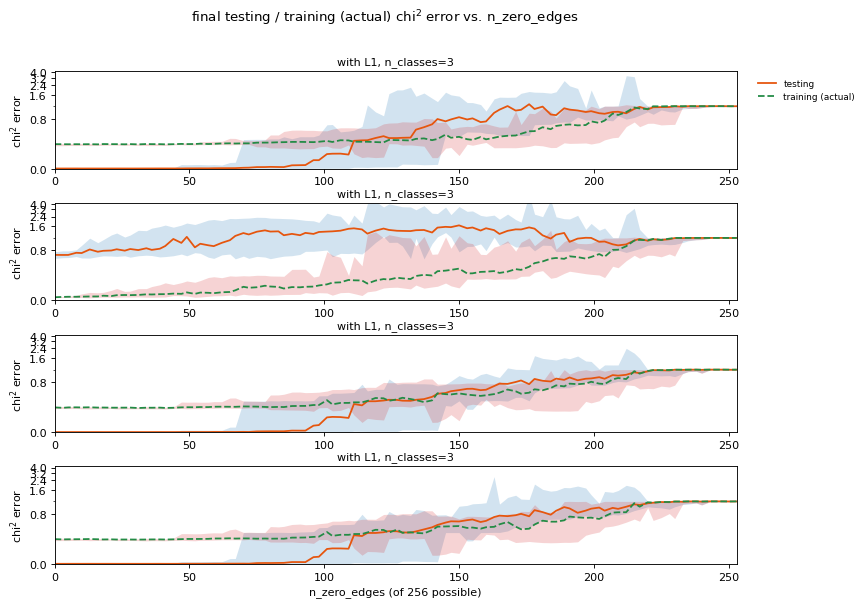

In [ ]:
with tp.teed(
    make_final_loss_plot,
    df,
    L1_CONDITIONS,
    N_CLASSES_VALUES,
    teeplot_outattrs={"dataset": "exploratory-edge-sparsity"},
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

## Plots 2 & 3: loss over evolutionary time, colored by n_zero_edges

Each panel overlays one median line per swept `n_zero_edges` value
(99 lines/panel) against generation (log-scaled, starting at 10^6),
colored by a continuous colormap (`n_zero_edges` -> viridis, shown
via a shared colorbar) rather than a discrete per-line legend --
with 99 distinct swept values, a discrete legend isn't practical
(unlike this project's earlier `v`-sweep notebooks, which had at
most 20 values). No min/max band is shown here (99 overlapping bands
would be unreadable); see plot 1 above for replicate spread at each
n. Y-axis is symlog (linear below chi^2=1, log above).

In [ ]:
def _use_readable_symlog_ticks(axis):
    axis.set_major_locator(MaxNLocator(nbins=6))
    axis.set_major_formatter(ScalarFormatter())

def make_over_time_plot(
    df, l1_conditions, n_classes_values, metric_col, metric_label
):
    GEN_LOG_FLOOR = 1e6
    CHI2_LINTHRESH = 1.0
    df = df[df["generation"] >= GEN_LOG_FLOOR]

    n_min = df["n_zero_edges"].min()
    n_max = df["n_zero_edges"].max()
    norm = Normalize(vmin=n_min, vmax=n_max)
    cmap = plt.get_cmap("viridis")

    fig = plt.figure(figsize=(12, 8), dpi=80)
    gs = GridSpec(
        len(l1_conditions),
        len(n_classes_values),
        figure=fig,
        hspace=0.35,
        wspace=0.25,
    )

    ax0 = None
    axes = []
    for row, (l1s, l2s, l1_label) in enumerate(l1_conditions):
        for col, ncls in enumerate(n_classes_values):
            if ax0 is None:
                ax = fig.add_subplot(gs[row, col])
                ax0 = ax
            else:
                ax = fig.add_subplot(gs[row, col], sharex=ax0, sharey=ax0)
            axes.append(ax)

            sub = df[
                (df["l1_scale"] == l1s)
                & (df["l2_scale"] == l2s)
                & (df["n_classes"] == ncls)
            ]
            agg = (
                sub.groupby(["n_zero_edges", "generation"], observed=True)[
                    metric_col
                ]
                .median()
                .reset_index()
            )
            for n_val, g in agg.groupby("n_zero_edges", observed=True):
                g = g.sort_values("generation")
                ax.plot(
                    g["generation"],
                    g[metric_col],
                    color=cmap(norm(n_val)),
                    lw=0.8,
                    alpha=0.85,
                )

            ax.set_xscale("log")
            ax.set_xlim(left=GEN_LOG_FLOOR)
            ax.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
            ax.set_ylim(bottom=0)
            _use_readable_symlog_ticks(ax.yaxis)
            ax.set_title(f"{l1_label}, n_classes={ncls}", fontsize=10)
            if row == len(l1_conditions) - 1:
                ax.set_xlabel("generation")
            if col == 0:
                ax.set_ylabel("chi$^2$ error")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, aspect=40)
    cbar.set_label("n_zero_edges (of 256 possible)")

    fig.suptitle(
        f"{metric_label} chi$^2$ error over evolutionary time",
        fontsize=12,
    )
    return fig

teeplots/2026-08-02exploratory-edge-sparsity-analysis/dataset=exploratory-edge-sparsity+metric=test+viz=make-over-time-plot+ext=.pdf
teeplots/2026-08-02exploratory-edge-sparsity-analysis/dataset=exploratory-edge-sparsity+metric=test+viz=make-over-time-plot+ext=.png



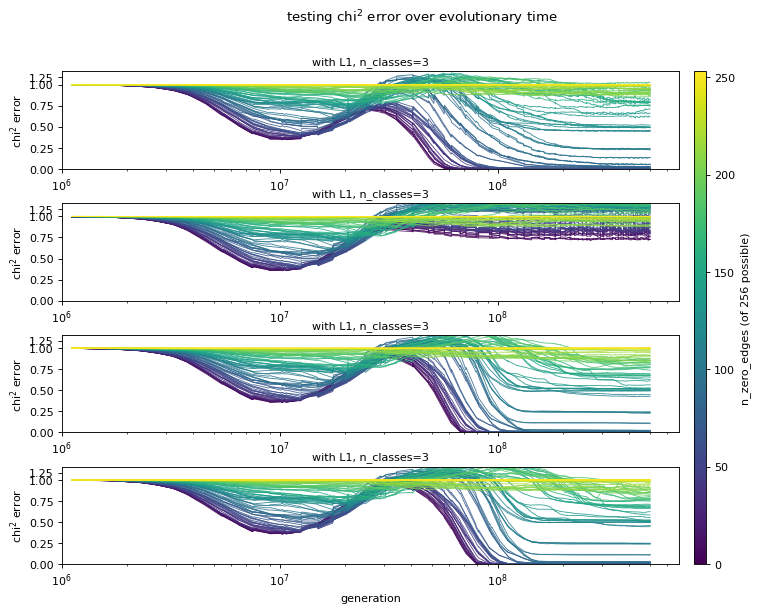

In [ ]:
with tp.teed(
    make_over_time_plot,
    df,
    L1_CONDITIONS,
    N_CLASSES_VALUES,
    "test_chi2",
    "testing",
    teeplot_outattrs={
        "dataset": "exploratory-edge-sparsity",
        "metric": "test",
    },
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

teeplots/2026-08-02exploratory-edge-sparsity-analysis/dataset=exploratory-edge-sparsity+metric=train+viz=make-over-time-plot+ext=.pdf
teeplots/2026-08-02exploratory-edge-sparsity-analysis/dataset=exploratory-edge-sparsity+metric=train+viz=make-over-time-plot+ext=.png



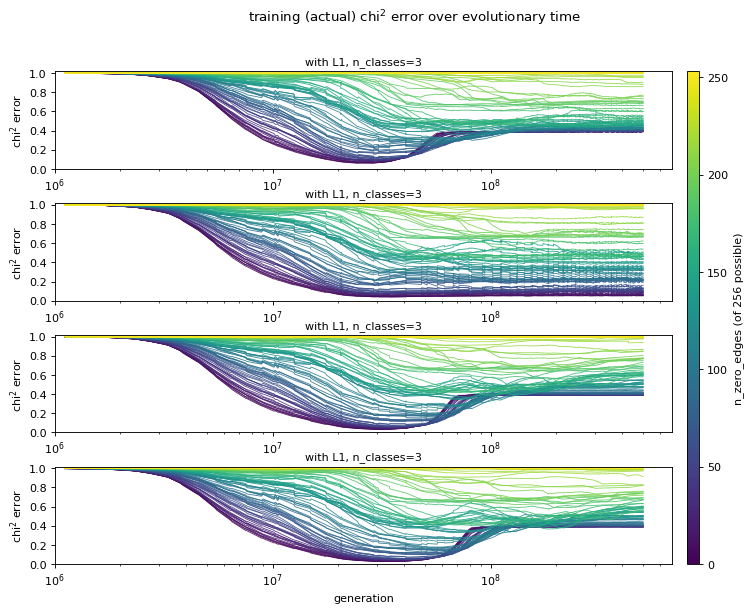

In [ ]:
with tp.teed(
    make_over_time_plot,
    df,
    L1_CONDITIONS,
    N_CLASSES_VALUES,
    "pure_train_chi2",
    "training (actual)",
    teeplot_outattrs={
        "dataset": "exploratory-edge-sparsity",
        "metric": "train",
    },
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)